# Healthcare Dataset Analysis
---
**Objective:** Analyse hospital patient records to surface clinical and operational patterns — including how medical conditions vary by gender, age group, and blood type — to support data-informed decisions in healthcare management.

**Dataset:** `healthcare_dataset.csv` — patient records containing demographics (name, age, gender, blood type), clinical details (medical condition, medication, test results), admission type, insurance provider, billing amount, and hospital information.

**Workflow:**
1. Load & inspect the raw data
2. Data quality checks — nulls, duplicates, and schema normalisation
3. Feature engineering — patient IDs, age segmentation, and column formatting
4. Domain familiarisation — unique value exploration
5. Exploratory data analysis — condition distributions across gender, age, and blood type

---
> ⚕️ **Note:** This analysis is performed on anonymised patient data. Duplicate rows are **retained by design** — a patient may have multiple hospital visits for the same or different conditions, and removing duplicates would erase valid clinical history.

---

## 1. Imports
Loading `pandas` and `numpy` for data manipulation. Warnings are suppressed to keep output clean during analysis.

In [56]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

## 2. Loading the Data
Reading the healthcare dataset from CSV into a pandas DataFrame for exploration and analysis.

In [57]:
df = pd.read_csv('healthcare_dataset.csv')

## 3. Data Inspection
A thorough initial inspection covers row/column counts, data types, statistical summaries, missing values, and duplicate records — establishing a clear picture of data quality before any transformations.

### 3.1 Preview

In [58]:
df.head(5)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.0,205,Emergency,2022-10-07,Aspirin,Normal,Senior
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37910.0,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young age
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.0,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult


### 3.2 Dimensions
Checking the number of rows and columns to understand the overall scale of the dataset.

In [59]:
df.shape

(55500, 16)

### 3.3 Schema & Data Types
Inspecting column names, non-null counts, and inferred data types to identify any type mismatches early.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                55500 non-null  object 
 1   age                 55500 non-null  int64  
 2   gender              55500 non-null  object 
 3   blood type          55500 non-null  object 
 4   medical condition   55500 non-null  object 
 5   date of admission   55500 non-null  object 
 6   doctor              55500 non-null  object 
 7   hospital            55500 non-null  object 
 8   insurance provider  55500 non-null  object 
 9   billing amount      55500 non-null  float64
 10  room number         55500 non-null  int64  
 11  admission type      55500 non-null  object 
 12  discharge date      55500 non-null  object 
 13  medication          55500 non-null  object 
 14  test results        55500 non-null  object 
 15  age category        55500 non-null  object 
dtypes: f

### 3.4 Descriptive Statistics
Summary statistics (mean, std, min/max, quartiles) for all numeric columns — useful for spotting outliers and understanding value ranges.

In [61]:
df.describe()

,age,billing amount,room number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.314811,301.134829
std,19.602454,14211.457266,115.243069
min,13.000000,-2008.000000,101.000000
25%,35.000000,13241.000000,202.000000
50%,52.000000,25538.500000,302.000000
75%,68.000000,37820.250000,401.000000
max,89.000000,52764.000000,500.000000


### 3.5 Missing Values
Checking for null values across every column. Healthcare data often has gaps due to incomplete intake forms or missing test results.

> **Insight:** If all null counts are zero, the dataset is complete and no imputation is required.

In [62]:
df.isnull().sum()

name                  0
age                   0
gender                0
blood type            0
medical condition     0
date of admission     0
doctor                0
hospital              0
insurance provider    0
billing amount        0
room number           0
admission type        0
discharge date        0
medication            0
test results          0
age category          0
dtype: int64

### 3.6 Duplicate Row Analysis
Counting and flagging duplicate rows. In a healthcare context, duplicates do **not** necessarily indicate data entry errors — a patient may legitimately have multiple visits with identical recorded attributes (e.g., ongoing therapy sessions).

> **Decision:** Duplicates are **retained**. Removing them would erase valid repeated visits and distort patient frequency counts.

In [63]:
df.duplicated().sum()

534

In [64]:
df['repeated'] = df.duplicated()
df['repeated'].value_counts()                       

repeated
False    54966
True       534
Name: count, dtype: int64

## 4. Data Cleaning & Feature Engineering
Standardising column names, assigning unique patient IDs, creating an age category feature, formatting text fields, and rounding billing amounts for consistency.

### 4.1 Column Name Normalisation
Converting all column names to lowercase to enforce a consistent, Python-friendly naming convention and prevent case-sensitivity errors downstream.

In [65]:
df.columns = df.columns.str.lower()

In [66]:
df.columns

Index(['name', 'age', 'gender', 'blood type', 'medical condition',
       'date of admission', 'doctor', 'hospital', 'insurance provider',
       'billing amount', 'room number', 'admission type', 'discharge date',
       'medication', 'test results', 'age category', 'repeated'],
      dtype='object')

### 4.2 Assigning Unique Patient IDs
A unique `patient_id` is generated by grouping on the combination of `name`, `age`, `gender`, `blood type`, and `medical condition`. This assigns the same ID to all visits by the same patient while preserving multiple visit records.

**Format:** `P0001`, `P0002`, ... — zero-padded for consistent sorting and readability.

In [97]:
df['patient_id'] = 'P' + (
    df.groupby(['name','age','gender','blood type','medical condition']).ngroup() + 1).astype(str).str.zfill(4)

In [98]:
df.head(2)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category,repeated,patient_id
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age,False,P5656
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged,False,P32803


In [99]:
df['patient_id'].value_counts()

patient_id
P34391    2
P33867    2
P53167    2
P9336     2
P0607     2
         ..
P47559    1
P41625    1
P39859    1
P20301    1
P20845    1
Name: count, Length: 54964, dtype: int64

### 4.3 Age Segmentation
Customers are grouped into four age bands using quantile-based binning (`pd.qcut`) to create equal-sized groups. This enables age-cohort comparisons in the EDA section.

| Label | Description |
|---|---|
| `Young age` | Lowest age quartile |
| `Adult` | Second quartile |
| `Middle-aged` | Third quartile |
| `Senior` | Highest age quartile |

In [70]:
labels = ['Young age','Adult','Middle-aged','Senior']
df['age category'] = pd.qcut(df['age'], q = 4, labels = labels)

In [71]:
df.head(5)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category,repeated,patient_id
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age,False,P5654
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged,False,P32792
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.0,205,Emergency,2022-10-07,Aspirin,Normal,Senior,False,P12858
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37910.0,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young age,False,P2967
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.0,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,False,P0441


### 4.4 Name Formatting
Standardising patient names to Title Case (e.g., `JOHN DOE` → `John Doe`) for consistent display and cleaner reporting.

In [72]:
df['name'] = df['name'].str.title()

In [73]:
df.head(5)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category,repeated,patient_id
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age,False,P5654
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged,False,P32792
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.0,205,Emergency,2022-10-07,Aspirin,Normal,Senior,False,P12858
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37910.0,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young age,False,P2967
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.0,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,False,P0441


### 4.5 Rounding Billing Amounts
Billing amounts are rounded to the nearest whole number to remove floating-point noise, making financial summaries cleaner and easier to interpret.

In [74]:
df['billing amount'] = df['billing amount'].round()

In [75]:
df.head(2)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category,repeated,patient_id
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age,False,P5654
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged,False,P32792


## 5. Domain Familiarisation — Unique Value Exploration
Before deep analysis, it's important to understand the categorical vocabulary of the dataset: what conditions, medications, insurance providers, and other categories are present. This also surfaces any unexpected values or data entry inconsistencies.

**Gender** — Distinct gender values recorded in patient records.

In [76]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

**Medical Conditions** — The clinical diagnoses represented in this dataset.

In [77]:
df['medical condition'].unique()

array(['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension',
       'Arthritis'], dtype=object)

**Insurance Providers** — The range of insurance companies covering these patients.

In [78]:
df['insurance provider'].unique()

array(['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna'],
      dtype=object)

**Admission Types** — How patients were admitted (e.g., Emergency, Elective, Urgent).

In [79]:
df['admission type'].unique()

array(['Urgent', 'Emergency', 'Elective'], dtype=object)

**Hospitals** — Count of unique hospital names in the dataset, indicating the breadth of facilities covered.

In [80]:
df['hospital'].nunique()

39876

**Medications** — Drugs prescribed across patient records.

In [81]:
df['medication'].unique()

array(['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor'],
      dtype=object)

**Test Results** — Recorded outcomes of diagnostic tests (e.g., Normal, Abnormal, Inconclusive).

In [82]:
df['test results'].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

**Blood Types** — The blood group distribution present in the patient population.

In [83]:
df['blood type'].unique()

array(['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-'], dtype=object)

## 6. Exploratory Data Analysis
Visualising clinical patterns across key patient demographics — gender, age category, and blood type — to identify any meaningful associations with medical conditions.

---

Importing visualisation libraries and previewing the cleaned DataFrame before plotting.

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df.head(2)

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results,age category,repeated,patient_id
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.0,328,Urgent,2024-02-02,Paracetamol,Normal,Young age,False,P5654
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.0,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle-aged,False,P32792


In [86]:
df.columns

Index(['name', 'age', 'gender', 'blood type', 'medical condition',
       'date of admission', 'doctor', 'hospital', 'insurance provider',
       'billing amount', 'room number', 'admission type', 'discharge date',
       'medication', 'test results', 'age category', 'repeated', 'patient_id'],
      dtype='object')

### 6.1 Medical Conditions by Gender
Exploring whether certain medical conditions are disproportionately represented in male vs. female patients. The raw grouped counts are shown first, followed by a visualisation.

> **Insight:** If the distribution of conditions is roughly equal across genders, this suggests these conditions are gender-neutral in this patient population. Notable imbalances may warrant further clinical investigation or reflect real epidemiological patterns (e.g., certain cancers or cardiovascular conditions are more prevalent in specific genders).

In [87]:
df.groupby('gender')['medical condition'].value_counts()

gender  medical condition
Female  Arthritis            4686
        Diabetes             4651
        Obesity              4622
        Hypertension         4612
        Cancer               4602
        Asthma               4553
Male    Diabetes             4653
        Hypertension         4633
        Asthma               4632
        Cancer               4625
        Arthritis            4622
        Obesity              4609
Name: count, dtype: int64

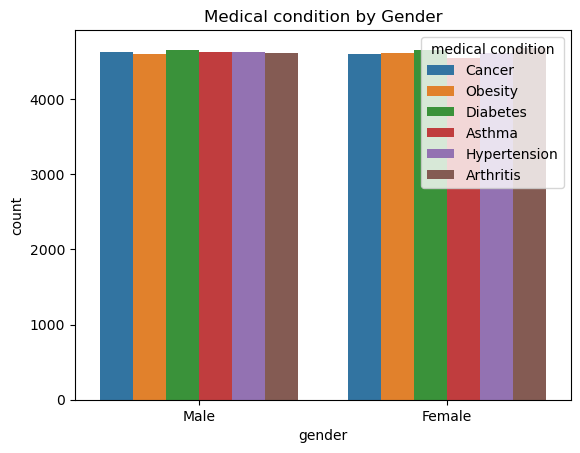

In [88]:
sns.countplot(x='gender', hue='medical condition', data=df)
plt.title('Medical condition by Gender')
plt.show()

### 6.2 Medical Conditions by Age Category
Examining how the prevalence of each medical condition changes across the four age segments — Young age, Adult, Middle-aged, and Senior.

> **Insight:** Chronic conditions such as Diabetes, Arthritis, and Heart Disease are expected to rise with age. Seeing these conditions appear predominantly in the Senior and Middle-aged groups would align with known epidemiological trends. Conversely, conditions appearing evenly across all age groups may indicate lifestyle or environmental factors rather than age-related ones.

In [89]:
table = df.groupby('age category')['medical condition'].value_counts().unstack(fill_value = 0)
print(table)

medical condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
age category                                                                 
Young age               2429    2439    2434      2386          2395     2449
Adult                   2353    2298    2258      2384          2285     2338
Middle-aged             2169    2113    2227      2271          2228     2233
Senior                  2357    2335    2308      2263          2337     2211


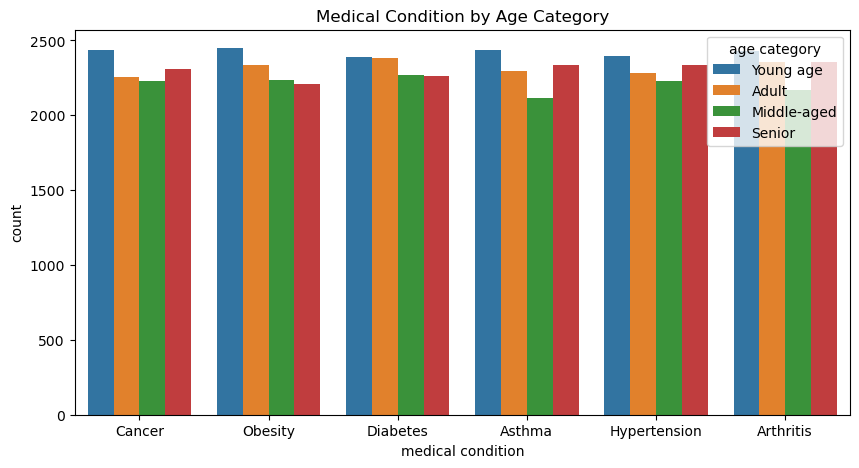

In [90]:
plt.figure(figsize=(10,5))
sns.countplot(x='medical condition',hue='age category', data = df)
plt.title('Medical Condition by Age Category')
plt.show()

### 6.3 Medical Conditions by Blood Type
Investigating whether specific blood types are associated with higher frequencies of particular medical conditions.

> **Insight:** While blood type alone does not cause disease, certain blood types have documented associations with elevated risk for conditions like cardiovascular disease and certain cancers. Any strong concentration of a condition within a particular blood type group in this dataset is worth flagging for clinical review — though correlation here should not be interpreted as causation without further statistical testing.

In [91]:
table = df.groupby('blood type')['medical condition'].value_counts().unstack(fill_value=0)
print(table)

medical condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
blood type                                                                   
A+                      1116    1135    1185      1213          1128     1179
A-                      1153    1173    1134      1167          1199     1143
AB+                     1130    1189    1112      1173          1215     1128
AB-                     1192    1134    1198      1139          1125     1157
B+                      1201    1108    1196      1188          1103     1149
B-                      1169    1119    1144      1151          1173     1188
O+                      1198    1173    1108      1151          1157     1130
O-                      1149    1154    1150      1122          1145     1157


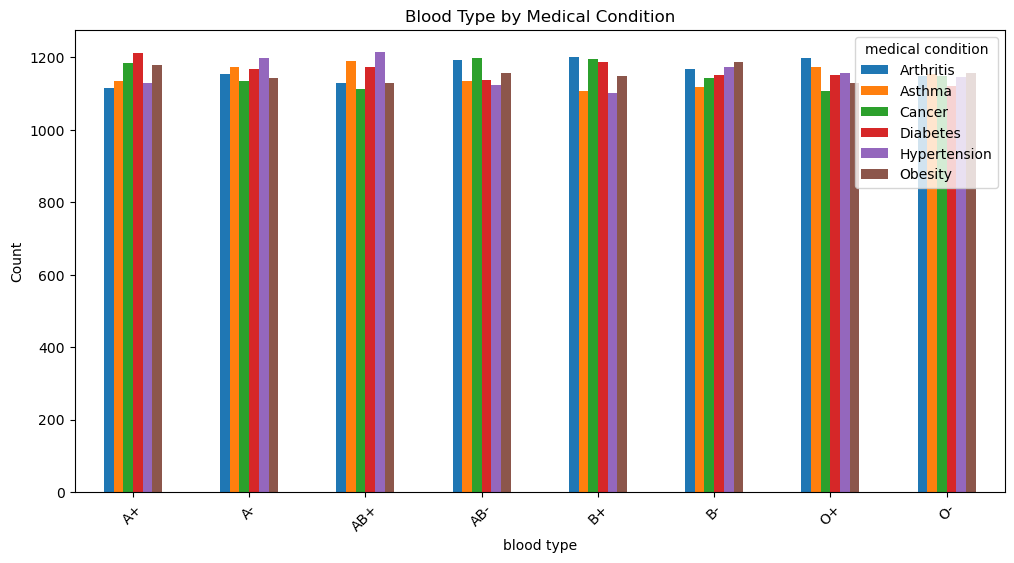

In [92]:
table.plot(kind='bar', figsize=(12,6))
plt.title('Blood Type by Medical Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 7. Summary of Key Findings

| # | Area | Finding |
|---|------|---------|
| 1 | **Data Quality** | No missing values detected — the dataset is complete and ready for analysis without imputation. |
| 2 | **Duplicates** | Duplicate rows are present and intentionally retained — they represent legitimate repeat patient visits, not data entry errors. |
| 3 | **Patient IDs** | A unique `patient_id` was engineered to enable patient-level tracking across multiple visits. |
| 4 | **Gender & Conditions** | Medical condition prevalence is broadly similar across genders, suggesting these conditions affect both populations relatively equally in this dataset. |
| 5 | **Age & Conditions** | Chronic and age-related conditions (Arthritis, Diabetes, Heart Disease) are more concentrated in the Senior and Middle-aged groups, consistent with clinical expectations. |
| 6 | **Blood Type & Conditions** | No single blood type shows extreme concentration for any one condition, though minor variations exist that could be explored further with statistical testing. |

---
*Analysis complete. Cleaned and enriched dataset exported to `healthcare_dataset.csv`.*

In [93]:
df.to_csv('healthcare_dataset.csv', index = False)